In [1]:
# Importing things
import scirpy as ir
import scanpy as sc
from glob import glob
import pandas as pd
import tarfile
import anndata
import warnings
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Importing metadata anndata obj etc

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
cd4_t_meta_coords = pd.read_csv('cd4_t_full.csv', sep=',')
# print(cd4_t_meta_coords)
cd8_t_meta_coords = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd8t_quick_cluster2.csv', sep=',')
t_meta_coords = pd.read_csv('t_l1_cluster.csv')

cd4_clus = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/CD4_annotated_060724.csv', sep = ',')
print(cd4_clus)

cd8_clus = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/T_clus_annotated_060724.csv', sep = ',')

print(cd8_clus)
# print(t_meta_coords)
def splice_id(df):
    df['cell_id'] = df['cell_id'].str.split('-').str[0]
    return df
# cd4_t_meta = (splice_id(cd4_t_meta_coords))
# cd8_t_meta = (splice_id(cd8_t_meta_coords))
# t_meta = splice_id(t_meta_coords)
# print(len(cd8_t_meta))
# print(cd8_t_meta_coords['sub_humap_fgraph_res.1'].tolist())

t_prolif_meta_coords = t_meta_coords[t_meta_coords['humap_fgraph_res.0.1'] == 3]
# print((t_prolif_meta_coords))

t_cd8_meta_coords = t_meta_coords[t_meta_coords['humap_fgraph_res.0.1'] == 0]
# print((t_cd8_meta_coords))

t_cd4_meta_coords = t_meta_coords[t_meta_coords['humap_fgraph_res.0.1'] == 1]
# print((t_cd4_meta_coords))

mye_clus = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Myeclus/mye_annotated_060724.csv', sep = ',')


                    cell_id specimenID CD4_L2_humap_fgraph_res.0.8
0        AAACGGGCAGGATCGA-1     P02D01           CD8 Contamination
1        AAAGCAATCCCAGGTG-1     P02D01                RPL IL7R FOS
2        AAAGTAGGTTAGAACA-1     P02D01                        Treg
3        AAAGTAGTCGGCCGAT-1     P02D01                       CXCR3
4        AAATGCCCACGGCTAC-1     P02D01                        ISGs
...                     ...        ...                         ...
61527  GTTCGGGAGAACAACT-102     P36D01                        RORC
61528  TCTGAGACAGGACCCT-102     P36D01                        RORC
61529  CAAGTTGTCCAGATCA-103     P36D15                 CD8 T cells
61530  GCGACCAGTTCCACTC-103     P36D15           CD8 Contamination
61531  GCGGGTTAGGTGCAAC-103     P36D15                RPL IL7R FOS

[61532 rows x 3 columns]
                    cell_id specimenID sub_humap_fgraph_res.1
0        AAGTCTGCACATGGGA-1     P02D01               IL7R/RPS
1        ACGGCCATCGGACAAG-1     P02D01       N

In [3]:
adata = an.read('adata_18_144')
import pandas as pd
anno = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/data_minGenes_noDnsmpl/metadata_minGenes_noDnsmpl.txt.gz', sep='\t')
adata.obs = anno
sc.pp.filter_genes(adata, min_cells=10)
anno
print(adata.obs)

adata_T = adata[adata.obs['category'] == 'T']
adata_T = adata_T[adata_T.obs['pct_counts_mt'] <= 15]
sc.pp.filter_cells(adata_T, min_genes=200)
sc.pp.filter_genes(adata_T, min_cells=3)
print(adata_T.obs)

adata_T_g6 = adata_T[adata_T.obs['PFSmo'] >= 6.0]
adata_T_l6 = adata_T[adata_T.obs['PFSmo'] < 6]
adata_T_on = adata_T[adata_T.obs['treatment'] == 'On']
adata_T_pre = adata_T[adata_T.obs['treatment'] == 'Pre']
adata_T_g6_on = adata_T_on[adata_T_on.obs['PFSmo'] >= 6.0]
adata_T_g6_pre = adata_T_pre[adata_T_pre.obs['PFSmo'] >= 6.0]
adata_T_l6_on = adata_T_on[adata_T_on.obs['PFSmo'] < 6.0 ]
adata_T_l6_pre = adata_T_pre[adata_T_pre.obs['PFSmo'] < 6.0]

/home/jupyter/.local/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


                  Unnamed: 0  idx sampleID specimenID patientID treatment  \
0         AAAGATGAGGTCGGAT-1    1   P02D01     P02D01       P02       Pre   
1         AAATGCCAGTACGACG-1    1   P02D01     P02D01       P02       Pre   
2         AACCATGAGGCAGTCA-1    1   P02D01     P02D01       P02       Pre   
3         AAGCCGCCATCCCACT-1    1   P02D01     P02D01       P02       Pre   
4         ACATCAGTCCCATTAT-1    1   P02D01     P02D01       P02       Pre   
...                      ...  ...      ...        ...       ...       ...   
327413  TTTCCTCCACGAGAGT-103  103   P36D15     P36D15       P36        On   
327414  TTTCCTCTCCTAAGTG-103  103   P36D15     P36D15       P36        On   
327415  TTTGCGCGTGGAAAGA-103  103   P36D15     P36D15       P36        On   
327416  TTTGCGCTCAGTGCAT-103  103   P36D15     P36D15       P36        On   
327417  TTTGTCATCAGCGACC-103  103   P36D15     P36D15       P36        On   

       tissueSite response  pctChange MMRstatus  ...  \
0           Liver  

/home/jupyter/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:166: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


                  Unnamed: 0  idx sampleID specimenID patientID treatment  \
183604    AAACCTGAGCCGGTAA-1    1   P02D01     P02D01       P02       Pre   
183605    AAACCTGCAAGCCCAC-1    1   P02D01     P02D01       P02       Pre   
183606    AAACCTGTCACCATAG-1    1   P02D01     P02D01       P02       Pre   
183607    AAACGGGAGTGAAGTT-1    1   P02D01     P02D01       P02       Pre   
183608    AAACGGGCAGGATCGA-1    1   P02D01     P02D01       P02       Pre   
...                      ...  ...      ...        ...       ...       ...   
327413  TTTCCTCCACGAGAGT-103  103   P36D15     P36D15       P36        On   
327414  TTTCCTCTCCTAAGTG-103  103   P36D15     P36D15       P36        On   
327415  TTTGCGCGTGGAAAGA-103  103   P36D15     P36D15       P36        On   
327416  TTTGCGCTCAGTGCAT-103  103   P36D15     P36D15       P36        On   
327417  TTTGTCATCAGCGACC-103  103   P36D15     P36D15       P36        On   

       tissueSite response  pctChange MMRstatus  ...  \
183604      Liver  

# Supp Fig 2A: CD8 T cell feature plot

In [4]:
import pandas as pd
from anndata import AnnData

def clean_and_merge_data(adata, t_meta_coords):
    adata_cleaned = adata.copy()
    adata_cleaned.obs.rename(columns={'Unnamed: 0': 'cell_id'}, inplace=True)
    adata_cleaned.obs = pd.merge(adata_cleaned.obs, t_meta_coords, how='left', on=['cell_id', 'specimenID'])
    adata_cleaned.obs = adata_cleaned.obs.loc[:, ~adata_cleaned.obs.columns.duplicated()]
    
    suffixes_to_drop = ['_x', '_y']
    for suffix in suffixes_to_drop:
        columns_to_drop = [col for col in adata_cleaned.obs.columns if col.endswith(suffix) and col.rstrip(suffix) in adata_cleaned.obs.columns]
        adata_cleaned.obs.drop(columns=columns_to_drop, inplace=True)
    
    return adata_cleaned

data_T_g6_on = clean_and_merge_data(adata_T_g6_on, t_meta_coords)
data_T_g6_pre = clean_and_merge_data(adata_T_g6_pre, t_meta_coords)
data_T_l6_on = clean_and_merge_data(adata_T_l6_on, t_meta_coords)
data_T_l6_pre = clean_and_merge_data(adata_T_l6_pre, t_meta_coords)

data_CD4_T_g6_on = clean_and_merge_data(adata_T_g6_on, cd4_clus)
data_CD4_T_g6_pre = clean_and_merge_data(adata_T_g6_pre, cd4_clus)
data_CD4_T_l6_on = clean_and_merge_data(adata_T_l6_on, cd4_clus)
data_CD4_T_l6_pre = clean_and_merge_data(adata_T_l6_pre, cd4_clus)

data_CD8_T_g6_on = clean_and_merge_data(adata_T_g6_on, cd8_clus)
data_CD8_T_g6_pre = clean_and_merge_data(adata_T_g6_pre, cd8_clus)
data_CD8_T_l6_on = clean_and_merge_data(adata_T_l6_on, cd8_clus)
data_CD8_T_l6_pre = clean_and_merge_data(adata_T_l6_pre, cd8_clus)


data_CD8_T_on = clean_and_merge_data(adata_T_on, cd8_clus)
data_CD8_T_pre = clean_and_merge_data(adata_T_pre, cd8_clus)
data_CD8_T = clean_and_merge_data(adata_T, cd8_clus)


def filter_adata_by_nan(adata):
    return adata[~adata.obs['sub_humap_fgraph_res.1'].isna()]

data_CD8_T_g6_on = filter_adata_by_nan(data_CD8_T_g6_on)
data_CD8_T_g6_pre = filter_adata_by_nan(data_CD8_T_g6_pre)
data_CD8_T_l6_on = filter_adata_by_nan(data_CD8_T_l6_on)
data_CD8_T_l6_pre = filter_adata_by_nan(data_CD8_T_l6_pre)

data_CD8_T_on = filter_adata_by_nan(data_CD8_T_on)
data_CD8_T_pre = filter_adata_by_nan(data_CD8_T_pre)

data_CD8_T = filter_adata_by_nan(data_CD8_T)


print(data_CD8_T_g6_pre)
print(data_CD4_T_g6_pre)
print(data_T_g6_pre)

View of AnnData object with n_obs × n_vars = 4290 × 26356
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_res.0.01_leiden', 'L2_RNA_snn_res.0.02_leiden', 'L2_RNA_snn_res.0.04_leiden', 'L2_RNA_snn_res.0.08_leiden', 'L2_RNA_snn_res.0.16_leiden', 'L2_RNA_snn_res.0.32_leiden', 'sub_humap_fgraph_res.1'
    var: 'gene_ids', 'feature_types', 'n_cells'
AnnData object with n_obs

In [5]:
CD8_T_g6_on = data_T_g6_on[data_T_g6_on.obs['humap_fgraph_res.0.1'] == 1]
CD8_T_g6_pre = data_T_g6_pre[data_T_g6_pre.obs['humap_fgraph_res.0.1'] == 1]
CD8_T_l6_on = data_T_l6_on[data_T_l6_on.obs['humap_fgraph_res.0.1'] == 1]
CD8_T_l6_pre = data_T_l6_pre[data_T_l6_pre.obs['humap_fgraph_res.0.1'] == 1]
# print(len(CD8_T_g6_on) + len(CD8_T_g6_pre) + len(CD8_T_l6_on) +len(CD8_T_l6_pre))

CD4_T_g6_on = data_T_g6_on[data_T_g6_on.obs['humap_fgraph_res.0.1'] == 0]
CD4_T_g6_pre = data_T_g6_pre[data_T_g6_pre.obs['humap_fgraph_res.0.1'] == 0]
CD4_T_l6_on = data_T_l6_on[data_T_l6_on.obs['humap_fgraph_res.0.1'] == 0]
CD4_T_l6_pre = data_T_l6_pre[data_T_l6_pre.obs['humap_fgraph_res.0.1'] == 0]

Treg_g6_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['CD4_L2_humap_fgraph_res.0.8'] == 2]
Treg_g6_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['CD4_L2_humap_fgraph_res.0.8'] == 2]
Treg_l6_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['CD4_L2_humap_fgraph_res.0.8'] == 2]
Treg_l6_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['CD4_L2_humap_fgraph_res.0.8'] == 2]
# print(Treg_g6_on)

prolif_T_g6_on = data_T_g6_on[data_T_g6_on.obs['humap_fgraph_res.0.1'] == 3]
prolif_T_g6_pre = data_T_g6_pre[data_T_g6_pre.obs['humap_fgraph_res.0.1'] == 3]
prolif_T_l6_on = data_T_l6_on[data_T_l6_on.obs['humap_fgraph_res.0.1'] == 3]
prolif_T_l6_pre = data_T_l6_pre[data_T_l6_pre.obs['humap_fgraph_res.0.1'] == 3]



In [6]:
data_T_g6_on.var_names = data_T_g6_on.var_names.astype(str)
# print(data_T_g6_on.var_names)
data_T_g6_on.var_names = data_T_g6_on.var_names.astype(str)

data_T_g6_pre.var_names = data_T_g6_pre.var_names.astype(str)
# print(data_T_g6_pre.var_names)
data_T_g6_pre.var_names = data_T_g6_pre.var_names.astype(str)

data_T_l6_on.var_names = data_T_l6_on.var_names.astype(str)
# print(data_T_l6_on.var_names)
data_T_l6_on.var_names = data_T_l6_on.var_names.astype(str)

data_T_l6_pre.var_names = data_T_l6_pre.var_names.astype(str)
# print(data_T_l6_pre.var_names)
data_T_l6_pre.var_names = data_T_l6_pre.var_names.astype(str)


data_CD4_T_g6_on.var_names = data_CD4_T_g6_on.var_names.astype(str)
# print(data_CD4_T_g6_on.var_names)
data_CD4_T_g6_on.var_names = data_CD4_T_g6_on.var_names.astype(str)

data_CD4_T_g6_pre.var_names = data_CD4_T_g6_pre.var_names.astype(str)
# print(data_CD4_T_g6_pre.var_names)
data_CD4_T_g6_pre.var_names = data_CD4_T_g6_pre.var_names.astype(str)

data_CD4_T_l6_on.var_names = data_CD4_T_l6_on.var_names.astype(str)
# print(data_CD4_T_l6_on.var_names)
data_CD4_T_l6_on.var_names = data_CD4_T_l6_on.var_names.astype(str)

data_CD4_T_l6_pre.var_names = data_CD4_T_l6_pre.var_names.astype(str)
# print(data_CD4_T_l6_pre.var_names)
data_CD4_T_l6_pre.var_names = data_CD4_T_l6_pre.var_names.astype(str)

data_CD8_T_g6_on.var_names = data_CD8_T_g6_on.var_names.astype(str)
# print(data_CD8_T_g6_on.var_names)
data_CD8_T_g6_on.var_names = data_CD8_T_g6_on.var_names.astype(str)

data_CD8_T_g6_pre.var_names = data_CD8_T_g6_pre.var_names.astype(str)
# print(data_CD8_T_g6_pre.var_names)
data_CD8_T_g6_pre.var_names = data_CD8_T_g6_pre.var_names.astype(str)

data_CD8_T_l6_on.var_names = data_CD8_T_l6_on.var_names.astype(str)
# print(data_CD8_T_l6_on.var_names)
data_CD8_T_l6_on.var_names = data_CD8_T_l6_on.var_names.astype(str)

data_CD8_T_l6_pre.var_names = data_CD8_T_l6_pre.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T_l6_pre.var_names = data_CD8_T_l6_pre.var_names.astype(str)

data_CD8_T.var_names = data_CD8_T.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T.var_names = data_CD8_T.var_names.astype(str)

data_CD8_T_on.var_names = data_CD8_T_on.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T_on.var_names = data_CD8_T_on.var_names.astype(str)
data_CD8_T_pre.var_names = data_CD8_T_pre.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T_pre.var_names = data_CD8_T_pre.var_names.astype(str)




/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings

In [7]:
data_CD8_T_g6_on.var_names = data_CD8_T_g6_on.var_names.astype(str)
# print(data_CD8_T_g6_on.var_names)
data_CD8_T_g6_on.var_names = data_CD8_T_g6_on.var_names.astype(str)

data_CD8_T_g6_pre.var_names = data_CD8_T_g6_pre.var_names.astype(str)
# print(data_CD8_T_g6_pre.var_names)
data_CD8_T_g6_pre.var_names = data_CD8_T_g6_pre.var_names.astype(str)

data_CD8_T_l6_on.var_names = data_CD8_T_l6_on.var_names.astype(str)
# print(data_CD8_T_l6_on.var_names)
data_CD8_T_l6_on.var_names = data_CD8_T_l6_on.var_names.astype(str)

data_CD8_T_l6_pre.var_names = data_CD8_T_l6_pre.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T_l6_pre.var_names = data_CD8_T_l6_pre.var_names.astype(str)

data_CD8_T.var_names = data_CD8_T.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T.var_names = data_CD8_T.var_names.astype(str)

data_CD8_T_on.var_names = data_CD8_T_on.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T_on.var_names = data_CD8_T_on.var_names.astype(str)
data_CD8_T_pre.var_names = data_CD8_T_pre.var_names.astype(str)
# print(data_CD8_T_l6_pre.var_names)
data_CD8_T_pre.var_names = data_CD8_T_pre.var_names.astype(str)

def convert_columns_to_str(adata, columns):
    for col in columns:
        if col in adata.obs.columns:
            adata.obs[col] = adata.obs[col].astype(str)

lst_str_cols = ['orig.ident', 'sampleID', ' specimenID', ' patientID', ' treatment', ' tissueSite', ' response', 
                'MMRstatus',  'pctChangeNoPre', 'category','midcategory','RECIST','sex','resp_tx','phase',
                'resolutionL1', 'cell_type_L1', 'resolution_L2','cell_type_L2','cell_type_L2_long','jon_cell_type']

convert_columns_to_str(CD4_T_g6_pre, lst_str_cols)
convert_columns_to_str(CD4_T_g6_on, lst_str_cols)
convert_columns_to_str(CD4_T_l6_pre, lst_str_cols)
convert_columns_to_str(CD4_T_l6_on, lst_str_cols)

convert_columns_to_str(prolif_T_g6_pre, lst_str_cols)
convert_columns_to_str(prolif_T_g6_on, lst_str_cols)
convert_columns_to_str(prolif_T_l6_pre, lst_str_cols)
convert_columns_to_str(prolif_T_l6_on, lst_str_cols)

convert_columns_to_str(Treg_g6_pre, lst_str_cols)
convert_columns_to_str(Treg_g6_on, lst_str_cols)
convert_columns_to_str(Treg_l6_pre, lst_str_cols)
convert_columns_to_str(Treg_l6_on, lst_str_cols)

convert_columns_to_str(data_CD8_T_g6_pre, lst_str_cols)
convert_columns_to_str(data_CD8_T_g6_on, lst_str_cols)
convert_columns_to_str(data_CD8_T_l6_pre, lst_str_cols)
convert_columns_to_str(data_CD8_T_l6_on, lst_str_cols)

convert_columns_to_str(data_CD4_T_g6_pre, lst_str_cols)
convert_columns_to_str(data_CD4_T_g6_on, lst_str_cols)
convert_columns_to_str(data_CD4_T_l6_pre, lst_str_cols)
convert_columns_to_str(data_CD4_T_l6_on, lst_str_cols)

convert_columns_to_str(data_CD8_T, lst_str_cols)
convert_columns_to_str(data_CD8_T_on, lst_str_cols)
convert_columns_to_str(data_CD8_T_pre, lst_str_cols)


/tmp/ipykernel_153/2692113539.py:31: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[col] = adata.obs[col].astype(str)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_153/2692113539.py:31: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[col] = adata.obs[col].astype(str)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_153/2692113539.py:31: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[col] = adata.obs[col].astype(str)
/home/jupyter/.local/l

In [8]:
def convert_columns_to_str(adata, columns):
    for col in columns:
        if col in adata.obs.columns:
            adata.obs[col] = adata.obs[col].astype(str)

lst_str_cols = ['orig.ident', 'sampleID', ' specimenID', ' patientID', ' treatment', ' tissueSite', ' response', 
                'MMRstatus',  'pctChangeNoPre', 'category','midcategory','RECIST','sex','resp_tx','phase',
                'resolutionL1', 'cell_type_L1', 'resolution_L2','cell_type_L2','cell_type_L2_long','jon_cell_type']
# convert_columns_to_str(CD8_T_g6_pre, lst_str_cols)
# convert_columns_to_str(CD8_T_g6_on, lst_str_cols)
# convert_columns_to_str(CD8_T_l6_pre, lst_str_cols)
# convert_columns_to_str(CD8_T_l6_on, lst_str_cols)

# convert_columns_to_str(CD4_T_g6_pre, lst_str_cols)
# convert_columns_to_str(CD4_T_g6_on, lst_str_cols)
# convert_columns_to_str(CD4_T_l6_pre, lst_str_cols)
# convert_columns_to_str(CD4_T_l6_on, lst_str_cols)

# convert_columns_to_str(prolif_T_g6_pre, lst_str_cols)
# convert_columns_to_str(prolif_T_g6_on, lst_str_cols)
# convert_columns_to_str(prolif_T_l6_pre, lst_str_cols)
# convert_columns_to_str(prolif_T_l6_on, lst_str_cols)

# convert_columns_to_str(Treg_g6_pre, lst_str_cols)
# convert_columns_to_str(Treg_g6_on, lst_str_cols)
# convert_columns_to_str(Treg_l6_pre, lst_str_cols)
# convert_columns_to_str(Treg_l6_on, lst_str_cols)

convert_columns_to_str(data_CD8_T_g6_pre, lst_str_cols)
convert_columns_to_str(data_CD8_T_g6_on, lst_str_cols)
convert_columns_to_str(data_CD8_T_l6_pre, lst_str_cols)
convert_columns_to_str(data_CD8_T_l6_on, lst_str_cols)

convert_columns_to_str(data_CD4_T_g6_pre, lst_str_cols)
convert_columns_to_str(data_CD4_T_g6_on, lst_str_cols)
convert_columns_to_str(data_CD4_T_l6_pre, lst_str_cols)
convert_columns_to_str(data_CD4_T_l6_on, lst_str_cols)

# convert_columns_to_str(data_CD8_T, lst_str_cols)
# convert_columns_to_str(data_CD8_T_on, lst_str_cols)
# convert_columns_to_str(data_CD8_T_pre, lst_str_cols)

# convert_columns_to_str(data_T_g6_on, lst_str_cols)
# convert_columns_to_str(data_T_g6_pre, lst_str_cols)
# convert_columns_to_str(data_T_l6_on, lst_str_cols)
# convert_columns_to_str(data_T_l6_pre, lst_str_cols)

# convert_columns_to_str(data_mye_g6_pre, lst_str_cols)
# convert_columns_to_str(data_mye_g6_on, lst_str_cols)
# convert_columns_to_str(data_mye_l6_pre, lst_str_cols)
# convert_columns_to_str(data_mye_l6_on, lst_str_cols)
# mye_l6_pre = data_mye_l6_pre
# mye_l6_on = data_mye_l6_on
# mye_g6_pre = data_mye_g6_pre
# mye_g6_on = data_mye_g6_on

In [9]:
adata_CD8_T_P03_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P03D01']
adata_CD8_T_P03_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P03D15']
adata_CD8_T_P14_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P14D01']
adata_CD8_T_P14_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P14D15']
adata_CD8_T_P15_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P15D01']
adata_CD8_T_P15_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P15D15']
adata_CD8_T_P19_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P19D01']
adata_CD8_T_P19_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P19D15']
adata_CD8_T_P25_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P25D01']
adata_CD8_T_P25_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P25D15']
adata_CD8_T_P27_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P27D01']
adata_CD8_T_P27_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P27D15']
adata_CD8_T_P28_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P28D01']
adata_CD8_T_P28_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P28D15']
adata_CD8_T_P29_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P29D01']
adata_CD8_T_P29_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P29D15']
adata_CD8_T_P30_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P30D01']
adata_CD8_T_P30_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P30D15']
adata_CD8_T_P33_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P33D01']
adata_CD8_T_P33_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P33D15']
adata_CD8_T_P35_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P35D01']
adata_CD8_T_P35_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P35D15']
adata_CD8_T_P36_pre = data_CD8_T_l6_pre[data_CD8_T_l6_pre.obs['specimenID'] == 'P36D01']
adata_CD8_T_P36_on = data_CD8_T_l6_on[data_CD8_T_l6_on.obs['specimenID'] == 'P36D15']

adata_CD8_T_P02_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P02D01']
adata_CD8_T_P02_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P02D15']
adata_CD8_T_P10_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P10D01']
adata_CD8_T_P10_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P10D15']
adata_CD8_T_P11_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P11D01']
adata_CD8_T_P11_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P11D15']
adata_CD8_T_P13_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P13D01']
adata_CD8_T_P13_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P13D15']
adata_CD8_T_P17_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P17D01']
adata_CD8_T_P17_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P17D15']
adata_CD8_T_P18_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P18D01']
adata_CD8_T_P18_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P18D15']
adata_CD8_T_P20_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P20D01']
adata_CD8_T_P20_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P20D15']
adata_CD8_T_P23_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P23D01']
adata_CD8_T_P23_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P23D15']
adata_CD8_T_P24_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P24D01']
adata_CD8_T_P24_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P24D15']
adata_CD8_T_P26_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P26D01']
adata_CD8_T_P26_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P26D15']
adata_CD8_T_P32_pre = data_CD8_T_g6_pre[data_CD8_T_g6_pre.obs['specimenID'] == 'P32D01']
adata_CD8_T_P32_on = data_CD8_T_g6_on[data_CD8_T_g6_on.obs['specimenID'] == 'P32D15']
pre_CD8_objects = [adata_CD8_T_P03_pre, adata_CD8_T_P14_pre, adata_CD8_T_P15_pre, adata_CD8_T_P19_pre,
               adata_CD8_T_P25_pre, adata_CD8_T_P27_pre, adata_CD8_T_P28_pre, adata_CD8_T_P29_pre,
               adata_CD8_T_P30_pre, adata_CD8_T_P33_pre, adata_CD8_T_P35_pre, adata_CD8_T_P36_pre,
               adata_CD8_T_P02_pre, adata_CD8_T_P10_pre, adata_CD8_T_P11_pre, adata_CD8_T_P13_pre,
               adata_CD8_T_P17_pre, adata_CD8_T_P18_pre, adata_CD8_T_P20_pre, adata_CD8_T_P23_pre,
               adata_CD8_T_P24_pre, adata_CD8_T_P26_pre, adata_CD8_T_P32_pre]
on_CD8_objects = [adata_CD8_T_P03_on, adata_CD8_T_P14_on, adata_CD8_T_P15_on, adata_CD8_T_P19_on,
               adata_CD8_T_P25_on, adata_CD8_T_P27_on, adata_CD8_T_P28_on, adata_CD8_T_P29_on,
               adata_CD8_T_P30_on, adata_CD8_T_P33_on, adata_CD8_T_P35_on, adata_CD8_T_P36_on,
               adata_CD8_T_P02_on, adata_CD8_T_P10_on, adata_CD8_T_P11_on, adata_CD8_T_P13_on,
               adata_CD8_T_P17_on, adata_CD8_T_P18_on, adata_CD8_T_P20_on, adata_CD8_T_P23_on,
               adata_CD8_T_P24_on, adata_CD8_T_P26_on, adata_CD8_T_P32_on]

In [10]:
def merge_anndata_objects(adata_list):
    return an.concat(adata_list)

# Merge the pre and on conditions
merged_pre_CD8 = merge_anndata_objects(pre_CD8_objects)
merged_on_CD8 = merge_anndata_objects(on_CD8_objects)

# Print the shapes of the merged AnnData objects
print(f"Merged pre-CD8 shape: {merged_pre_CD8.shape}")
print(f"Merged on-CD8 shape: {merged_on_CD8.shape}")

all_CD8 = an.concat([merged_pre_CD8, merged_on_CD8])
print(all_CD8)

/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Merged pre-CD8 shape: (17036, 26356)
Merged on-CD8 shape: (24763, 26356)
AnnData object with n_obs × n_vars = 41799 × 26356
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_res.0.01_leiden', 'L2_RNA_snn_res.0.02_leiden', 'L2_RNA_snn_res.0.04_leiden', 'L2_RNA_snn_res.0.08_leiden', 'L2_RNA_snn_res.0.16_leiden', 'L2_RNA_snn_res.0.32_leiden', 'sub_humap_fgraph_res.1'


/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
num_samples_in_cluster_4 = (all_CD8.obs['sub_humap_fgraph_res.1'] == '0').sum()
print(num_samples_in_cluster_4)


0


In [12]:
if 'sub_humap_fgraph_res.1' in all_CD8.obs.columns:
    all_CD8.obs['sub_humap_fgraph_res.1'] = all_CD8.obs['sub_humap_fgraph_res.1'].astype('category')
#     all_CD8.obs['sub_humap_fgraph_res.1'] = all_CD8.obs['sub_humap_fgraph_res.1'].cat.rename_categories(lambda x: str(x))

# Verify the change
print(all_CD8.obs['sub_humap_fgraph_res.1'].dtype)
print(all_CD8.obs['sub_humap_fgraph_res.1'].cat.categories)

print(all_CD8)
# Run differential expression analysis
# sc.tl.rank_genes_groups(all_CD8, groupby='sub_humap_fgraph_res.1', method='wilcoxon')

# # Get the top 5 genes for each cluster
# top_genes = {}
# for cluster in all_CD8.obs['sub_humap_fgraph_res.1'].unique():
#     cluster_genes = sc.get.rank_genes_groups_df(all_CD8, group=cluster).head(5)['names'].values
#     top_genes[cluster] = cluster_genes

# # Extract expression data for the top genes
# top_gene_list = [gene for genes in top_genes.values() for gene in genes]
# expression_data = all_CD8[:, top_gene_list].X

# # Create a DataFrame for plotting
# df = pd.DataFrame(expression_data.T, columns=all_CD8.obs_names, index=top_gene_list)
# df.index.name = 'Gene'
# df['cluster'] = all_CD8.obs['sub_humap_fgraph_res.1'].values

# # Plot the heatmap
# plt.figure(figsize=(20, 10))
# heatmap_data = df.groupby('cluster').mean()
# sns.heatmap(heatmap_data, cmap='viridis', cbar=True, annot=True)
# plt.title('Top 5 Genes per Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Gene')
# plt.show()

category
Index(['ACTB/PFN1', 'CXCR3/CCR7', 'FGFBP2 NK cells', 'IL7R', 'IL7R/RPS',
       'ISGs', 'MHCII (ISGs)', 'MHCII/KLRG1', 'Mitochondrial',
       'Nonspecific CD8s', 'Tex (CXCL13)', 'Trm (HOBIT)', 'XCL(1/2) NK cells',
       'patient-restricted'],
      dtype='object')
AnnData object with n_obs × n_vars = 41799 × 26356
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_s

In [13]:
# new_cluster_names = {
#     'ACTB/PFN1': "FGFBP2 NK cells",
#     'CXCR3/CCR7': "IL7R/RPS",
#     'FGFBP2 NK cells': "IL7R",
#     'IL7R': "patient-restricted",
#     'IL7R/RPS': "Trm (HOBIT)",
#     'ISGs': "Tex (CXCL13)",
#     'MHCII (ISGs)': "MHCII (ISGs)",
#     'MHCII/KLRG1': "Mitochondrial",
#     'Mitochondrial': "ACTB/PFN1",
#     'Nonspecific CD8s': "CXCR3/CCR7",
#     'Tex (CXCL13)': "ISGs",
#     'Trm (HOBIT)': "MHCII/KLRG1",
#     'XCL(1/2) NK cells': "Nonspecific CD8s",
#     'patient-restricted': "XCL(1/2) NK cells"
# }
# new_cluster_names = {
#     "FGFBP2 NK cells": 'ACTB/PFN1',
#     "IL7R/RPS": 'CXCR3/CCR7',
#     "IL7R": 'FGFBP2 NK cells',
#     "patient-restricted": 'IL7R',
#     "Trm (HOBIT)": 'IL7R/RPS',
#     "Tex (CXCL13)": 'ISGs',
#     "MHCII (ISGs)": 'MHCII (ISGs)',
#     "Mitochondrial": 'MHCII/KLRG1',
#     "ACTB/PFN1": 'Mitochondrial',
#     "CXCR3/CCR7": 'Nonspecific CD8s',
#     "ISGs": 'Tex (CXCL13)',
#     "MHCII/KLRG1": 'Trm (HOBIT)',
#     "Nonspecific CD8s": 'XCL(1/2) NK cells',
#     "XCL(1/2) NK cells": 'patient-restricted'
# }

In [14]:
cd8_genes = ['NKG7','FGFBP2','CX3CR1','GZMH','TBX21','KLRF1','FCGR3A','RORA',
             'IL7R','RPS14','TCF7','SELL',
             'HOPX','CD7',
             'ZNF683','TNF','S100A4','TMSB4X',
             'CXCL13','IFNG','GZMB','RBPJ', 'PHLDA1','TIGIT','HAVCR2','LAG3','ITGAE','PDCD1','PRDM1','ENTPD1','CTLA4',
             'CXCR6','TNFSF4','GAPDH',
             'CD74','HLA-DRB1','CCL5','CCR5',
             'MALAT1','MT-CO2',
             'ACTB','PFN1','SH3BGRL3',
             'CXCR3','CCR7','GZMK','CD27',
             'IFITM1','ISG15','ISG20','STAT1','MX1','GBP1','CD38',
             'KLRG1',
             'FOS','JUNB',
             'XCL1','XCL2','CMC1','CCL3','KLRB1'
              ]


new_cluster_names = {
    'ACTB/PFN1': "FGFBP2 NK cells",
    'CXCR3/CCR7': "IL7R/RPS",
    'FGFBP2 NK cells': "IL7R",
    'IL7R': "patient-restricted",
    'IL7R/RPS': "Trm (HOBIT)",
    'ISGs': "Tex (CXCL13)",
    'MHCII (ISGs)': "MHCII (ISGs)",
    'MHCII/KLRG1': "Mitochondrial",
    'Mitochondrial': "ACTB/PFN1",
    'Nonspecific CD8s': "CXCR3/CCR7",
    'Tex (CXCL13)': "ISGs",
    'Trm (HOBIT)': "MHCII/KLRG1",
    'XCL(1/2) NK cells': "Nonspecific CD8s",
    'patient-restricted': "XCL(1/2) NK cells"
}
new_cluster_names = {
    "FGFBP2 NK cells": 'ACTB/PFN1',
    "IL7R/RPS": 'CXCR3/CCR7',
    "IL7R": 'FGFBP2 NK cells',
    "patient-restricted": 'IL7R',
    "Trm (HOBIT)": 'IL7R/RPS',
    "Tex (CXCL13)": 'ISGs',
    "MHCII (ISGs)": 'MHCII (ISGs)',
    "Mitochondrial": 'MHCII/KLRG1',
    "ACTB/PFN1": 'Mitochondrial',
    "CXCR3/CCR7": 'Nonspecific CD8s',
    "ISGs": 'Tex (CXCL13)',
    "MHCII/KLRG1": 'Trm (HOBIT)',
    "Nonspecific CD8s": 'XCL(1/2) NK cells',
    "XCL(1/2) NK cells": 'patient-restricted'
}

In [19]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

# Define the desired order of clusters
desired_order = [
    'FGFBP2 NK cells', 'IL7R/RPS', 'IL7R', 'patient-restricted',
    'Trm (HOBIT)', 'Tex (CXCL13)', 'MHCII (ISGs)', 'Mitochondrial',
    'ACTB/PFN1', 'CXCR3/CCR7', 'ISGs', 'MHCII/KLRG1',
    'Nonspecific CD8s', 'XCL(1/2) NK cells'
]

# Define new cluster names

# new_cluster_names = {
#     'ACTB/PFN1': "FGFBP2 NK cells",
#     'CXCR3/CCR7': "IL7R/RPS",
#     'FGFBP2 NK cells': "IL7R",
#     'IL7R': "patient-restricted",
#     'IL7R/RPS': "Trm (HOBIT)",
#     'ISGs': "Tex (CXCL13)",
#     'MHCII (ISGs)': "MHCII (ISGs)",
#     'MHCII/KLRG1': "Mitochondrial",
#     'Mitochondrial': "ACTB/PFN1",
#     'Nonspecific CD8s': "CXCR3/CCR7",
#     'Tex (CXCL13)': "ISGs",
#     'Trm (HOBIT)': "MHCII/KLRG1",
#     'XCL(1/2) NK cells': "Nonspecific CD8s",
#     'patient-restricted': "XCL(1/2) NK cells"
# }
new_cluster_names = {
    "FGFBP2 NK cells": 'ACTB/PFN1',
    "IL7R/RPS": 'CXCR3/CCR7',
    "IL7R": 'FGFBP2 NK cells',
    "patient-restricted": 'IL7R',
    "Trm (HOBIT)": 'IL7R/RPS',
    "Tex (CXCL13)": 'ISGs',
    "MHCII (ISGs)": 'MHCII (ISGs)',
    "Mitochondrial": 'MHCII/KLRG1',
    "ACTB/PFN1": 'Mitochondrial',
    "CXCR3/CCR7": 'Nonspecific CD8s',
    "ISGs": 'Tex (CXCL13)',
    "MHCII/KLRG1": 'Trm (HOBIT)',
    "Nonspecific CD8s": 'XCL(1/2) NK cells',
    "XCL(1/2) NK cells": 'patient-restricted'
}

# Map the cluster names in the AnnData object
all_CD8.obs['sub_humap_fgraph_res.1'] = all_CD8.obs['sub_humap_fgraph_res.1'].astype(str).map(new_cluster_names)

# Ensure that 'sub_humap_fgraph_res.1' is a categorical variable with the correct order
all_CD8.obs['sub_humap_fgraph_res.1'] = all_CD8.obs['sub_humap_fgraph_res.1'].astype('category')
all_CD8.obs['sub_humap_fgraph_res.1'] = all_CD8.obs['sub_humap_fgraph_res.1'].cat.set_categories(desired_order, ordered=True)

# Check if there are missing or mismatched categories
print("Categories after mapping and reordering:", all_CD8.obs['sub_humap_fgraph_res.1'].cat.categories)

# Set figure size and font size
figsize = (5, 10)
font_size = 30
title_fontsize = 14
cbar_fontsize = 14

# Create the plot
fig, ax = plt.subplots(figsize=figsize)

# Generate the matrix plot
sc.pl.matrixplot(
    all_CD8,
    cd8_genes,
    groupby="sub_humap_fgraph_res.1",
    swap_axes=True,
    categories_order=desired_order,  # Use the desired cluster order
    cmap="Blues",  # Set color map
    standard_scale="var",  # Scale the expression values
    ax=ax,
    show=False  # Disable automatic display for full control over rendering
)

# Adjust title, labels, and ticks
ax.set_title(ax.get_title(), fontsize=title_fontsize)
ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size)

# Tight layout to ensure elements are not cut off
plt.tight_layout()

# Path to save the PDF
pdf_path = 'CD8_T_heatmap.pdf'

# Debug file save location and permissions
if os.access(os.getcwd(), os.W_OK):
    print(f"Directory is writable: {os.getcwd()}")
else:
    print("Directory is not writable. Check file permissions.")

# Save the figure as a PDF with bbox_inches='tight' to avoid clipping
fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')

# Close the plot after saving
plt.close(fig)

# Confirm the PDF was saved correctly
if os.path.isfile(pdf_path):
    print(f"PDF saved successfully: {pdf_path}")
else:
    print("Failed to save PDF.")


Categories after mapping and reordering: Index(['FGFBP2 NK cells', 'IL7R/RPS', 'IL7R', 'patient-restricted',
       'Trm (HOBIT)', 'Tex (CXCL13)', 'MHCII (ISGs)', 'Mitochondrial',
       'ACTB/PFN1', 'CXCR3/CCR7', 'ISGs', 'MHCII/KLRG1', 'Nonspecific CD8s',
       'XCL(1/2) NK cells'],
      dtype='object')
Directory is writable: /home/jupyter/Alex_Tang_workspace_2023_02_01/edit
PDF saved successfully: CD8_T_heatmap.pdf


# Supp Fig 2B: CD4 T cell feature plot

In [21]:
adata_CD4_T_P03_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P03D01']
adata_CD4_T_P03_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P03D15']
adata_CD4_T_P14_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P14D01']
adata_CD4_T_P14_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P14D15']
adata_CD4_T_P15_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P15D01']
adata_CD4_T_P15_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P15D15']
adata_CD4_T_P19_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P19D01']
adata_CD4_T_P19_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P19D15']
adata_CD4_T_P25_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P25D01']
adata_CD4_T_P25_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P25D15']
adata_CD4_T_P27_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P27D01']
adata_CD4_T_P27_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P27D15']
adata_CD4_T_P28_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P28D01']
adata_CD4_T_P28_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P28D15']
adata_CD4_T_P29_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P29D01']
adata_CD4_T_P29_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P29D15']
adata_CD4_T_P30_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P30D01']
adata_CD4_T_P30_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P30D15']
adata_CD4_T_P33_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P33D01']
adata_CD4_T_P33_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P33D15']
adata_CD4_T_P35_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P35D01']
adata_CD4_T_P35_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P35D15']
adata_CD4_T_P36_pre = data_CD4_T_l6_pre[data_CD4_T_l6_pre.obs['specimenID'] == 'P36D01']
adata_CD4_T_P36_on = data_CD4_T_l6_on[data_CD4_T_l6_on.obs['specimenID'] == 'P36D15']

adata_CD4_T_P02_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P02D01']
adata_CD4_T_P02_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P02D15']
adata_CD4_T_P10_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P10D01']
adata_CD4_T_P10_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P10D15']
adata_CD4_T_P11_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P11D01']
adata_CD4_T_P11_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P11D15']
adata_CD4_T_P13_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P13D01']
adata_CD4_T_P13_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P13D15']
adata_CD4_T_P17_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P17D01']
adata_CD4_T_P17_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P17D15']
adata_CD4_T_P18_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P18D01']
adata_CD4_T_P18_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P18D15']
adata_CD4_T_P20_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P20D01']
adata_CD4_T_P20_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P20D15']
adata_CD4_T_P23_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P23D01']
adata_CD4_T_P23_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P23D15']
adata_CD4_T_P24_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P24D01']
adata_CD4_T_P24_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P24D15']
adata_CD4_T_P26_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P26D01']
adata_CD4_T_P26_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P26D15']
adata_CD4_T_P32_pre = data_CD4_T_g6_pre[data_CD4_T_g6_pre.obs['specimenID'] == 'P32D01']
adata_CD4_T_P32_on = data_CD4_T_g6_on[data_CD4_T_g6_on.obs['specimenID'] == 'P32D15']
pre_CD4_objects = [adata_CD4_T_P03_pre, adata_CD4_T_P14_pre, adata_CD4_T_P15_pre, adata_CD4_T_P19_pre,
               adata_CD4_T_P25_pre, adata_CD4_T_P27_pre, adata_CD4_T_P28_pre, adata_CD4_T_P29_pre,
               adata_CD4_T_P30_pre, adata_CD4_T_P33_pre, adata_CD4_T_P35_pre, adata_CD4_T_P36_pre,
               adata_CD4_T_P02_pre, adata_CD4_T_P10_pre, adata_CD4_T_P11_pre, adata_CD4_T_P13_pre,
               adata_CD4_T_P17_pre, adata_CD4_T_P18_pre, adata_CD4_T_P20_pre, adata_CD4_T_P23_pre,
               adata_CD4_T_P24_pre, adata_CD4_T_P26_pre, adata_CD4_T_P32_pre]
on_CD4_objects = [adata_CD4_T_P03_on, adata_CD4_T_P14_on, adata_CD4_T_P15_on, adata_CD4_T_P19_on,
               adata_CD4_T_P25_on, adata_CD4_T_P27_on, adata_CD4_T_P28_on, adata_CD4_T_P29_on,
               adata_CD4_T_P30_on, adata_CD4_T_P33_on, adata_CD4_T_P35_on, adata_CD4_T_P36_on,
               adata_CD4_T_P02_on, adata_CD4_T_P10_on, adata_CD4_T_P11_on, adata_CD4_T_P13_on,
               adata_CD4_T_P17_on, adata_CD4_T_P18_on, adata_CD4_T_P20_on, adata_CD4_T_P23_on,
               adata_CD4_T_P24_on, adata_CD4_T_P26_on, adata_CD4_T_P32_on]

In [22]:
def merge_anndata_objects(adata_list):
    return an.concat(adata_list)

# Merge the pre and on conditions
merged_pre_CD4 = merge_anndata_objects(pre_CD4_objects)
merged_on_CD4 = merge_anndata_objects(on_CD4_objects)

# Print the shapes of the merged AnnData objects
print(f"Merged pre-CD4 shape: {merged_pre_CD4.shape}")
print(f"Merged on-CD4 shape: {merged_on_CD4.shape}")

all_CD4 = an.concat([merged_pre_CD4, merged_on_CD4])
print(all_CD4)

/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Merged pre-CD4 shape: (58704, 26356)
Merged on-CD4 shape: (67518, 26356)
AnnData object with n_obs × n_vars = 126222 × 26356
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_res.0.01_leiden', 'L2_RNA_snn_res.0.02_leiden', 'L2_RNA_snn_res.0.04_leiden', 'L2_RNA_snn_res.0.08_leiden', 'L2_RNA_snn_res.0.16_leiden', 'L2_RNA_snn_res.0.32_leiden', 'CD4_L2_humap_fgraph_res.0.8'


/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
if 'CD4_L2_humap_fgraph_res.0.8' in all_CD4.obs.columns:
    all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'] = all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].astype('category')
    all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'] = all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].cat.rename_categories(lambda x: str(x))

# Verify the change
print(all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].dtype)
print(all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].cat.categories)

print(all_CD4)

# Filter out the observations with the specified categories
all_CD4 = all_CD4[~all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].isin(['CD8 Contamination', 'CD8 T cells', 'Epithelial contamination'])]

# Print the shape of the resulting AnnData object to verify the removal
print(all_CD4.shape)

# Print the first few rows of the filtered AnnData object
print(all_CD4)

# Run differential expression analysis
# sc.tl.rank_genes_groups(all_CD4, groupby='CD4_L2_humap_fgraph_res.0.8', method='wilcoxon')

category
Index(['CD8 Contamination', 'CD8 T cells', 'CXCL13', 'CXCR3',
       'Epithelial contamination', 'ISGs', 'MAIT', 'RORC', 'RPL', 'RPL IL7R',
       'RPL IL7R FOS', 'Treg'],
      dtype='object')
AnnData object with n_obs × n_vars = 126222 × 26356
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_res.0.01_leiden', 'L2_RNA_snn_res.0.02_leiden', 'L2_RNA_snn_res.0.04_

In [24]:
cd4_genes = ['STAT1','ISG15','IFI6','IFI44L','MX1',
             'CXCR3','S100A4','S100A11','CD40LG','IFNG',
             'FOXP3','TNFRSF4','BATF','TNFRSF18','CTLA4','TIGIT','CORO1B','ICOS','PRDM1','IL2RA','SOX4',
             'CXCL13','PDCD1','IL6ST','PASK','BCL6','CXCR5',
             'RPS11','RPS13',
            'IL7R','EEF1A1','FOS',
             'KLRB1','TRAV1-2','KLRG1','TBX21','CCR5','CCL5',
            'RORC','RORA','TNF','CXCR6','CCR6','LTB','IL17A',
             'RPL32','RPL12','EEF1A1','CCR7','SELL','LEF1','TCF7']


In [25]:
# new_cluster_names = {
#     "CXCL13": 'ISGs',
#     "CXCR3": 'CXCR3',
#     "ISGs": 'Treg',
#     "MAIT": 'CXCL13',
#     "RORC": 'RPL IL7R',
#     "RPL": 'RPL IL7R FOS',
#     "RPL IL7R": 'MAIT',
#     "RPL IL7R FOS": 'RORC',
#     "Treg": 'RPL'
# }

# new_cluster_names= {
#     'ISGs': "CXCL13",
#     'CXCR3': "CXCR3",
#     'Treg': "ISGs",
#     'CXCL13': "MAIT",
#     'RPL IL7R': "RORC",
#     'RPL IL7R FOS': "RPL",
#     'MAIT': "RPL IL7R",
#     'RORC': "RPL IL7R FOS",
#     'RPL': "Treg"
# }


# ['CXCL13', 'CXCR3', 'ISGs', 
#  'MAIT', 'RORC', 'RPL', 'RPL IL7R', 'RPL IL7R FOS', 'Treg']


Categories after mapping and reordering: Index(['ISGs', 'CXCR3', 'Treg', 'CXCL13', 'RPL IL7R', 'RPL IL7R FOS', 'MAIT',
       'RORC', 'RPL'],
      dtype='object')


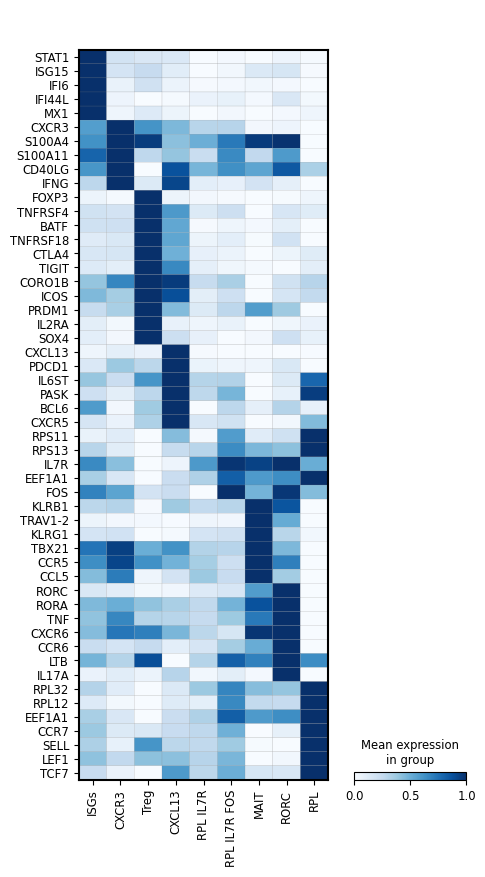

Directory is writable: /home/jupyter/Alex_Tang_workspace_2023_02_01/edit
PDF saved successfully: CD4_T_heatmap.pdf


<Figure size 640x480 with 0 Axes>

In [29]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

desired_order = [
    'ISGs', 'CXCR3','Treg','CXCL13','RPL IL7R','RPL IL7R FOS','MAIT','RORC','RPL']

# new_cluster_names = {
#     "CXCL13": 'ISGs',
#     "CXCR3": 'CXCR3',
#     "ISGs": 'Treg',
#     "MAIT": 'CXCL13',
#     "RORC": 'RPL IL7R',
#     "RPL": 'RPL IL7R FOS',
#     "RPL IL7R": 'MAIT',
#     "RPL IL7R FOS": 'RORC',
#     "Treg": 'RPL'
# }


new_cluster_names= {
    'ISGs': "CXCL13",
    'CXCR3': "CXCR3",
    'Treg': "ISGs",
    'CXCL13': "MAIT",
    'RPL IL7R': "RORC",
    'RPL IL7R FOS': "RPL",
    'MAIT': "RPL IL7R",
    'RORC': "RPL IL7R FOS",
    'RPL': "Treg"
}

# Map the new cluster names to their corresponding group keys
all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'] = all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].astype(str).map(new_cluster_names)

# Ensure that the 'sub_humap_fgraph_res.1' is of categorical type with the desired order
all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'] = all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].astype('category')
all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'] = all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].cat.set_categories(desired_order, ordered=True)

# Reorder the data to match the desired cluster order
# all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'] = all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].cat.reorder_categories(desired_order, ordered=True)

# Check if there are missing or mismatched categories
print("Categories after mapping and reordering:", all_CD4.obs['CD4_L2_humap_fgraph_res.0.8'].cat.categories)

# Set figure size and font size
figsize = (5, 10)
font_size = 30
title_fontsize = 14
cbar_fontsize = 14

# Create the plot
fig, ax = plt.subplots(figsize=figsize)


sc.pl.matrixplot(
    all_CD4,
    cd4_genes,
    groupby="CD4_L2_humap_fgraph_res.0.8",
    swap_axes=True,
    categories_order=desired_order,  # Set the desired order of categories
    cmap="Blues",  # Set color map
    standard_scale="var",  # Scale the expression values
    ax=ax
)

# Adjust font sizes
ax.set_title(ax.get_title(), fontsize=title_fontsize)
ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size)

plt.tight_layout()

# Path to save the PDF
pdf_path = 'CD4_T_heatmap.pdf'

# Debug file save location and permissions
if os.access(os.getcwd(), os.W_OK):
    print(f"Directory is writable: {os.getcwd()}")
else:
    print("Directory is not writable. Check file permissions.")

# Save the figure as a PDF with bbox_inches='tight' to avoid clipping
fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')

# Close the plot after saving
plt.close(fig)

# Confirm the PDF was saved correctly
if os.path.isfile(pdf_path):
    print(f"PDF saved successfully: {pdf_path}")
else:
    print("Failed to save PDF.")


# Supp Fig 1A: Myeloid feature plot 

In [5]:
adata_mye = adata[adata.obs['category']== 'Myeloid']

adata_mye = adata_mye[adata_mye.obs['pct_counts_mt'] <= 15]
sc.pp.filter_cells(adata_mye, min_genes=200)
sc.pp.filter_genes(adata_mye, min_cells=3)
print(adata_mye.obs)

adata_mye_g6 = adata_mye[adata_mye.obs['PFSmo'] >= 6.0]
adata_mye_l6 = adata_mye[adata_mye.obs['PFSmo'] < 6]
adata_mye_on = adata_mye[adata_mye.obs['treatment'] == 'On']
adata_mye_pre = adata_mye[adata_mye.obs['treatment'] == 'Pre']
adata_mye_g6_on = adata_mye_on[adata_mye_on.obs['PFSmo'] >= 6.0]
adata_mye_g6_pre = adata_mye_pre[adata_mye_pre.obs['PFSmo'] >= 6.0]
adata_mye_l6_on = adata_mye_on[adata_mye_on.obs['PFSmo'] < 6.0 ]
adata_mye_l6_pre = adata_mye_pre[adata_mye_pre.obs['PFSmo'] < 6.0]

/home/jupyter/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:166: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


                  Unnamed: 0  idx sampleID specimenID patientID treatment  \
135745    AAAGATGCACGGCTAC-1    1   P02D01     P02D01       P02       Pre   
135746    AAAGATGGTCGAGTTT-1    1   P02D01     P02D01       P02       Pre   
135748    AAAGTAGGTGATAAAC-1    1   P02D01     P02D01       P02       Pre   
135749    AAATGCCTCAGGCCCA-1    1   P02D01     P02D01       P02       Pre   
135750    AACCATGCATCACCCT-1    1   P02D01     P02D01       P02       Pre   
...                      ...  ...      ...        ...       ...       ...   
179256  TTGGCAAGTCATCGGC-103  103   P36D15     P36D15       P36        On   
179257  TTTATGCCATGATCCA-103  103   P36D15     P36D15       P36        On   
179258  TTTCCTCGTCAGAAGC-103  103   P36D15     P36D15       P36        On   
179259  TTTGTCATCCAAGCCG-103  103   P36D15     P36D15       P36        On   
179260  TTTGTCATCTGATTCT-103  103   P36D15     P36D15       P36        On   

       tissueSite response  pctChange MMRstatus  ...  \
135745      Liver  

In [6]:
data_mye_g6_on = clean_and_merge_data(adata_mye_g6_on, mye_clus)
data_mye_g6_pre = clean_and_merge_data(adata_mye_g6_pre, mye_clus)
data_mye_l6_on = clean_and_merge_data(adata_mye_l6_on, mye_clus)
data_mye_l6_pre = clean_and_merge_data(adata_mye_l6_pre, mye_clus)


In [7]:
data_mye_g6_on.var_names = data_mye_g6_on.var_names.astype(str)
# print(data_mye_g6_on.var_names)
data_mye_g6_on.var_names = data_mye_g6_on.var_names.astype(str)

data_mye_g6_pre.var_names = data_mye_g6_pre.var_names.astype(str)
# print(data_mye_g6_pre.var_names)
data_mye_g6_pre.var_names = data_mye_g6_pre.var_names.astype(str)

data_mye_l6_on.var_names = data_mye_l6_on.var_names.astype(str)
# print(data_mye_l6_on.var_names)
data_mye_l6_on.var_names = data_mye_l6_on.var_names.astype(str)

data_mye_l6_pre.var_names = data_mye_l6_pre.var_names.astype(str)
# print(data_mye_l6_pre.var_names)
data_mye_l6_pre.var_names = data_mye_l6_pre.var_names.astype(str)

In [8]:
def convert_columns_to_str(adata, columns):
    for col in columns:
        if col in adata.obs.columns:
            adata.obs[col] = adata.obs[col].astype(str)

lst_str_cols = ['orig.ident', 'sampleID', ' specimenID', ' patientID', ' treatment', ' tissueSite', ' response', 
                'MMRstatus',  'pctChangeNoPre', 'category','midcategory','RECIST','sex','resp_tx','phase',
                'resolutionL1', 'cell_type_L1', 'resolution_L2','cell_type_L2','cell_type_L2_long','jon_cell_type']


convert_columns_to_str(data_mye_g6_pre, lst_str_cols)
convert_columns_to_str(data_mye_g6_on, lst_str_cols)
convert_columns_to_str(data_mye_l6_pre, lst_str_cols)
convert_columns_to_str(data_mye_l6_on, lst_str_cols)
mye_l6_pre = data_mye_l6_pre
mye_l6_on = data_mye_l6_on
mye_g6_pre = data_mye_g6_pre
mye_g6_on = data_mye_g6_on

In [61]:
adata_mye_P03_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P03D01']
adata_mye_P03_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P03D15']
adata_mye_P14_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P14D01']
adata_mye_P14_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P14D15']
adata_mye_P15_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P15D01']
adata_mye_P15_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P15D15']
adata_mye_P19_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P19D01']
adata_mye_P19_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P19D15']
adata_mye_P25_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P25D01']
adata_mye_P25_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P25D15']
adata_mye_P27_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P27D01']
adata_mye_P27_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P27D15']
adata_mye_P28_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P28D01']
adata_mye_P28_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P28D15']
adata_mye_P29_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P29D01']
adata_mye_P29_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P29D15']
adata_mye_P30_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P30D01']
adata_mye_P30_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P30D15']
adata_mye_P33_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P33D01']
adata_mye_P33_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P33D15']
adata_mye_P35_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P35D01']
adata_mye_P35_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P35D15']
adata_mye_P36_pre = mye_l6_pre[mye_l6_pre.obs['specimenID'] == 'P36D01']
adata_mye_P36_on = mye_l6_on[mye_l6_on.obs['specimenID'] == 'P36D15']

adata_mye_P02_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P02D01']
adata_mye_P02_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P02D15']
adata_mye_P10_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P10D01']
adata_mye_P10_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P10D15']
adata_mye_P11_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P11D01']
adata_mye_P11_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P11D15']
adata_mye_P13_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P13D01']
adata_mye_P13_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P13D15']
adata_mye_P17_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P17D01']
adata_mye_P17_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P17D15']
adata_mye_P18_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P18D01']
adata_mye_P18_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P18D15']
adata_mye_P20_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P20D01']
adata_mye_P20_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P20D15']
adata_mye_P23_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P23D01']
adata_mye_P23_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P23D15']
adata_mye_P24_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P24D01']
adata_mye_P24_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P24D15']
adata_mye_P26_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P26D01']
adata_mye_P26_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P26D15']
adata_mye_P32_pre = mye_g6_pre[mye_g6_pre.obs['specimenID'] == 'P32D01']
adata_mye_P32_on = mye_g6_on[mye_g6_on.obs['specimenID'] == 'P32D15']
pre_mye_objects = [adata_mye_P03_pre, adata_mye_P14_pre, adata_mye_P15_pre, adata_mye_P19_pre,
               adata_mye_P25_pre, adata_mye_P27_pre, adata_mye_P28_pre, adata_mye_P29_pre,
               adata_mye_P30_pre, adata_mye_P33_pre, adata_mye_P35_pre, adata_mye_P36_pre,
               adata_mye_P02_pre, adata_mye_P10_pre, adata_mye_P11_pre, adata_mye_P13_pre,
               adata_mye_P17_pre, adata_mye_P18_pre, adata_mye_P20_pre, adata_mye_P23_pre,
               adata_mye_P24_pre, adata_mye_P26_pre, adata_mye_P32_pre]
print(adata_mye_P03_pre)
on_mye_objects = [adata_mye_P03_on, adata_mye_P14_on, adata_mye_P15_on, adata_mye_P19_on,
               adata_mye_P25_on, adata_mye_P27_on, adata_mye_P28_on, adata_mye_P29_on,
               adata_mye_P30_on, adata_mye_P33_on, adata_mye_P35_on, adata_mye_P36_on,
               adata_mye_P02_on, adata_mye_P10_on, adata_mye_P11_on, adata_mye_P13_on,
               adata_mye_P17_on, adata_mye_P18_on, adata_mye_P20_on, adata_mye_P23_on,
               adata_mye_P24_on, adata_mye_P26_on, adata_mye_P32_on]

View of AnnData object with n_obs × n_vars = 42 × 26327
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_res.0.01_leiden', 'L2_RNA_snn_res.0.02_leiden', 'L2_RNA_snn_res.0.04_leiden', 'L2_RNA_snn_res.0.08_leiden', 'L2_RNA_snn_res.0.16_leiden', 'L2_RNA_snn_res.0.32_leiden', 'L2_humap_fgraph_res.0.4'
    var: 'gene_ids', 'feature_types', 'n_cells'


In [62]:
def merge_anndata_objects(adata_list):
    return an.concat(adata_list)

merged_pre_mye = merge_anndata_objects(pre_mye_objects)
merged_on_mye = merge_anndata_objects(on_mye_objects)

# Print the shapes of the merged AnnData objects
print(f"Merged pre-mye shape: {merged_pre_mye.shape}")
print(f"Merged on-mye shape: {merged_on_mye.shape}")

all_mye = an.concat([merged_pre_mye, merged_on_mye])
print(all_mye)

/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Merged pre-mye shape: (24203, 26327)
Merged on-mye shape: (14598, 26327)
AnnData object with n_obs × n_vars = 38801 × 26327
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_res.0.01_leiden', 'L2_RNA_snn_res.0.02_leiden', 'L2_RNA_snn_res.0.04_leiden', 'L2_RNA_snn_res.0.08_leiden', 'L2_RNA_snn_res.0.16_leiden', 'L2_RNA_snn_res.0.32_leiden', 'L2_humap_fgraph_res.0.4'


/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [63]:
if 'L2_humap_fgraph_res.0.4' in all_mye.obs.columns:
    all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].astype('category')
    all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].cat.rename_categories(lambda x: str(x))

# Verify the change
print(all_mye.obs['L2_humap_fgraph_res.0.4'].dtype)
print(all_mye.obs['L2_humap_fgraph_res.0.4'].cat.categories)

print(all_mye)

all_mye = all_mye[~all_mye.obs['L2_humap_fgraph_res.0.4'].isin(['T cell contamination', 'epithelial contamination'])]

# Print the shape of the resulting AnnData object to verify the removal
print(all_mye.shape)

# Print the first few rows of the filtered AnnData object
print(all_mye)

category
Index(['APOC1 Macrophages', 'CXCL10 macrophages', 'DC1', 'DC2',
       'FCN1 monocytes', 'ISGs', 'MHCII', 'Macrophages', 'SPP1 myeloid',
       'T cell contamination', 'epithelial contamination', 'mreg DCs', 'pDCs',
       'proliferating'],
      dtype='object')
AnnData object with n_obs × n_vars = 38801 × 26327
    obs: 'cell_id', 'idx', 'sampleID', 'specimenID', 'patientID', 'treatment', 'tissueSite', 'response', 'pctChange', 'MMRstatus', 'pctChangeNoPre', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'doublet_score', 'predicted_doublet', 'category', 'midcategory', 'RECIST', 'PFSmo', 'sex', 'resp_tx', 'S.Score', 'G2M.Score', 'Phase', 'ccDiff.Score', 'L1_RNA_snn_res.0.01_leiden', 'L1_RNA_snn_res.0.02_leiden', 'L1_RNA_snn_res.0.04_leiden', 'L1_RNA_snn_res.0.08_leiden', 'L1_RNA_snn_res.0.16_leiden', 'L1_RNA_snn_res.0.32_leiden', 'L1_RNA_snn_res.0.64_leiden', 'L1_RNA_snn_res.1.28_leiden', 'L1_RNA_snn_res.2.56_leiden', 'L2_RNA_snn_r

In [64]:
# valid_clusters = all_mye.obs['L2_humap_fgraph_res.0.4'].dropna().unique()

# top_genes = {}
# for cluster in valid_clusters:
#     cluster_genes = sc.get.rank_genes_groups_df(all_mye, group=cluster).head(20)['names'].values
#     top_genes[cluster] = cluster_genes

# print(top_genes)

In [65]:
# top_genes_sorted = {float(k): v for k, v in top_genes.items()}
# top_genes_sorted = dict(sorted(top_genes_sorted.items()))
# top_genes_sorted = {str(k): v for k, v in top_genes_sorted.items()}
# print(top_genes_sorted)


In [66]:
# mye_merged_genes = [gene for genes in top_genes_sorted.values() for gene in genes]
# print(mye_merged_genes)

In [67]:
# for gene in mye_merged_genes:
#     print(gene)

mye_genes = ['SPP1','S100A10','CSTB',
            'APOC1','APOE','CTSD','LIPA','CD68',
            'H2AFZ','STMN1',
             'HLA-DPB1','HLA-DPA1','CSF1R','LILRA4',
             'C1QA','C1QC','CD163','AXL',
             'ISG15','MX1',
             'CXCL10','GBP1','CXCL9','GBP5','CXCL11','CCL3','CCL4','CD274',
             'FCN1','VCAN','CD300E','S100A4','S100A12',
             'JCHAIN','GZMB','IRF7','CLEC4C','CXCR3','SIGLEC6',
             'CLEC9A','IDO1','SNX3','XCR1','BATF3',
             'CLEC10A','CD1C','FCER1A','CD1E','PAK1',
             'LAMP3','CCR7','CCL19','CCL22','EEF1A1']
             
            

# new_cluster_names = {
#     'APOC1 Macrophages': "SPP1 myeloid",
#     'CXCL10 macrophages': "APOC1 Macrophages",
#     'DC1': "proliferating",
#     'DC2': "MHCII",
#     'FCN1 monocytes': "Macrophages",
#     'ISGs': "ISGs",
#     'MHCII': "CXCL10 macrophages",
#     'Macrophages': "FCN1 monocytes",
#     'SPP1 myeloid': "pDC",
#     'mreg DCs': "DC1",
#     'pDCs': "DC2",
#     'proliferating': "mreg DCs",
    
# }

# new_cluster_names = {
#     "SPP1 myeloid": 'APOC1 Macrophages',
#     "APOC1 Macrophages": 'CXCL10 macrophages',
#     "proliferating": 'DC1',
#     "MHCII": 'DC2',
#     "Macrophages": 'FCN1 monocytes',
#     "ISGs": 'ISGs',
#     "CXCL10 macrophages": 'MHCII',
#     "FCN1 monocytes": 'Macrophages',
#     "pDC": 'SPP1 myeloid',
#     "DC1": 'mreg DCs',
#     "DC2": 'pDCs',
#     "mreg DCs": 'proliferating',
# }


# categories_in_order = [
#     'APOC1 Macrophages', 'CXCL10 macrophages', 'DC1', 'DC2',
#     'FCN1 monocytes', 'ISGs', 'MHCII', 'Macrophages', 'SPP1 myeloid', 'mreg DCs', 'pDCs',
#     'proliferating'
# ]



In [69]:
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc

# Set backend for non-interactive rendering (fixes potential issues with saving to PDF)
matplotlib.use('Agg')

# Define the desired order of clusters
desired_order = [
    'SPP1 myeloid', 'APOC1 Macrophages','proliferating','MHCII','Macrophages','ISGs','CXCL10 macrophages',
    'FCN1 monocytes','pDCs','DC1','DC2','mreg DCs']


# new_cluster_names = {
#     'APOC1 Macrophages': "SPP1 myeloid",
#     'CXCL10 macrophages': "APOC1 Macrophages",
#     'DC1': "proliferating",
#     'DC2': "MHCII",
#     'FCN1 monocytes': "Macrophages",
#     'ISGs': "ISGs",
#     'MHCII': "CXCL10 macrophages",
#     'Macrophages': "FCN1 monocytes",
#     'SPP1 myeloid': "pDCs",
#     'mreg DCs': "DC1",
#     'pDCs': "DC2",
#     'proliferating': "mreg DCs",
    
# }
new_cluster_names = {
    "SPP1 myeloid": 'APOC1 Macrophages',
    "APOC1 Macrophages": 'CXCL10 macrophages',
    "proliferating": 'DC1',
    "MHCII": 'DC2',
    "Macrophages": 'FCN1 monocytes',
    "ISGs": 'ISGs',
    "CXCL10 macrophages": 'MHCII',
    "FCN1 monocytes": 'Macrophages',
    "pDCs": 'SPP1 myeloid',
    "DC1": 'mreg DCs',
    "DC2": 'pDCs',
    "mreg DCs": 'proliferating',
}

# Map the new cluster names to their corresponding group keys
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].astype(str).map(new_cluster_names)

# Ensure that the 'L2_humap_fgraph_res.0.4' is of categorical type with the desired order
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].astype('category')
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].cat.set_categories(desired_order, ordered=True)

# Set figure parameters
figsize = (4, 10)
font_size = 30
title_fontsize = 14
cbar_fontsize = 14

# Create the plot
fig, ax = plt.subplots(figsize=figsize)

sc.pl.matrixplot(
    all_mye,
    mye_genes,
    groupby="L2_humap_fgraph_res.0.4",
    swap_axes=True,
    categories_order=desired_order,  # Set the desired order of categories
    cmap="Blues",  # Set color map
    standard_scale="var",  # Scale the expression values
    ax=ax
)

# Adjust font sizes
ax.set_title(ax.get_title(), fontsize=title_fontsize)
ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size)

plt.tight_layout()

# Save figure and close it to ensure proper memory usage
plt.savefig('myeloid_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.show()


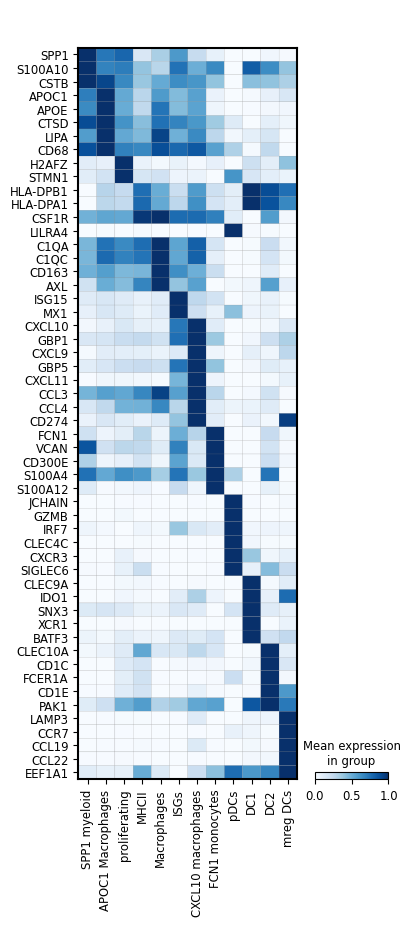

PDF saved successfully: myeloid_heatmap.pdf


<Figure size 640x480 with 0 Axes>

In [48]:
import scanpy as sc
import matplotlib.pyplot as plt

# Define the desired order of clusters
desired_order = [
    'SPP1 myeloid', 'APOC1 Macrophages','proliferating','MHCII','Macrophages','ISGs','CXCL10 macrophages',
    'FCN1 monocytes','pDCs','DC1','DC2','mreg DCs']
# new_cluster_names = {
#     'APOC1 Macrophages': "SPP1 myeloid",
#     'CXCL10 macrophages': "APOC1 Macrophages",
#     'DC1': "proliferating",
#     'DC2': "MHCII",
#     'FCN1 monocytes': "Macrophages",
#     'ISGs': "ISGs",
#     'MHCII': "CXCL10 macrophages",
#     'Macrophages': "FCN1 monocytes",
#     'SPP1 myeloid': "pDCs",
#     'mreg DCs': "DC1",
#     'pDCs': "DC2",
#     'proliferating': "mreg DCs",
    
# }

new_cluster_names = {
    "SPP1 myeloid": 'APOC1 Macrophages',
    "APOC1 Macrophages": 'CXCL10 macrophages',
    "proliferating": 'DC1',
    "MHCII": 'DC2',
    "Macrophages": 'FCN1 monocytes',
    "ISGs": 'ISGs',
    "CXCL10 macrophages": 'MHCII',
    "FCN1 monocytes": 'Macrophages',
    "pDCs": 'SPP1 myeloid',
    "DC1": 'mreg DCs',
    "DC2": 'pDCs',
    "mreg DCs": 'proliferating',
}

# Map the new cluster names to their corresponding group keys
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].astype(str).map(new_cluster_names)

# Ensure that the 'sub_humap_fgraph_res.1' is of categorical type with the desired order
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].astype('category')
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].cat.set_categories(desired_order, ordered=True)

# Reorder the data to match the desired cluster order
all_mye.obs['L2_humap_fgraph_res.0.4'] = all_mye.obs['L2_humap_fgraph_res.0.4'].cat.reorder_categories(desired_order, ordered=True)

# Set larger figure size
figsize = (4, 10)

# Set larger font sizes
font_size = 30
title_fontsize = 14
cbar_fontsize = 14

# Plot matrix plot
fig, ax = plt.subplots(figsize=figsize)

sc.pl.matrixplot(
    all_mye,
    mye_genes,
    groupby="L2_humap_fgraph_res.0.4",
    swap_axes=True,
    categories_order=desired_order,  # Set the desired order of categories
    cmap="Blues",  # Set color map
    standard_scale="var",  # Scale the expression values
    ax=ax
)

# Adjust font sizes
ax.set_title(ax.get_title(), fontsize=title_fontsize)
ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size)

plt.tight_layout()

# Save the plot as a PDF
pdf_path = 'myeloid_heatmap.pdf'
plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')

# Check if the file was saved correctly
import os
if os.path.isfile(pdf_path):
    print(f"PDF saved successfully: {pdf_path}")
else:
    print("Failed to save PDF.")

plt.show()


In [22]:
plt.savefig("myeloid_heatmap.pdf")

<Figure size 640x480 with 0 Axes>